In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install wfdb numpy pandas scipy matplotlib tqdm --quiet

import os
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import resample
from tqdm import tqdm
import matplotlib.pyplot as plt

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 73.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


In [ ]:
TARGET_FS = 500
TARGET_SECONDS = 10
TARGET_LEN = TARGET_FS * TARGET_SECONDS   # = 5000
NUM_LEADS = 12

In [ ]:
DRIVE_ROOT = '/content/drive/MyDrive/LSTS/ecg_benchmark'
RAW_DIR = '/content/raw'          # disposable, lives in Colab session only
PROCESSED_DIR = f'{DRIVE_ROOT}/processed'   # persists to shared Drive

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

In [ ]:
# %% CELL 2 — Download PTB-XL as a single zip (much faster than recursive crawl)
!wget -q --show-progress -O {RAW_DIR}/ptbxl.zip \
  https://physionet.org/content/ptb-xl/get-zip/1.0.3/

!unzip -q {RAW_DIR}/ptbxl.zip -d {RAW_DIR}

# The zip extracts into a folder named after the full project title — find it
import glob
PTBXL_DIR = glob.glob(f'{RAW_DIR}/ptb-xl*')[0]
print("PTB-XL downloaded to:", PTBXL_DIR)

/content/raw/ptbxl. 100%[===================>]   1.71G   322KB/s    in 93m 48s 
PTB-XL downloaded to: /content/raw/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


In [ ]:
!wget -r -N -c -np -q --show-progress \
  -P {RAW_DIR} \
  https://physionet.org/files/challenge-2020/1.0.2/training/cpsc_2018/

CPSC_DIR = f'{RAW_DIR}/physionet.org/files/challenge-2020/1.0.2/training/cpsc_2018'
print("CPSC2018 downloaded to:", CPSC_DIR)

Streaming output truncated to the last 5000 lines.
physionet.org/files 100%[===================>]     677  --.-KB/s    in 0s      
physionet.org/files 100%[===================>] 388.15K   325KB/s    in 1.2s    
physionet.org/files 100%[===================>]     707  --.-KB/s    in 0s      
physionet.org/files 100%[===================>] 187.52K   355KB/s    in 0.5s    
physionet.org/files 100%[===================>]     673  --.-KB/s    in 0s      
physionet.org/files 100%[===================>] 138.56K   346KB/s    in 0.4s    
physionet.org/files 100%[===================>]     690  --.-KB/s    in 0s      
physionet.org/files 100%[===================>] 117.21K   414KB/s    in 0.3s    
physionet.org/files 100%[===================>]     698  --.-KB/s    in 0s      
physionet.org/files 100%[===================>] 140.65K   362KB/s    in 0.4s    
physionet.org/files 100%[===================>]     704  --.-KB/s    in 0s      
physionet.org/files 100%[===================>] 316.43K   332KB/s    i

In [ ]:
def standardize_signal(sig, orig_fs, target_fs=TARGET_FS, target_len=TARGET_LEN):
    """
    Takes a raw (leads x samples) or (samples x leads) array and returns
    a fixed-shape (NUM_LEADS, TARGET_LEN) array at TARGET_FS.
    """
    # Ensure shape is (leads, samples)
    if sig.shape[0] != NUM_LEADS and sig.shape[1] == NUM_LEADS:
        sig = sig.T

    # Resample to target_fs if needed
    if orig_fs != target_fs:
        new_n_samples = int(sig.shape[1] * target_fs / orig_fs)
        sig = resample(sig, new_n_samples, axis=1)

    # Pad or truncate to fixed length
    n = sig.shape[1]
    if n < target_len:
        pad = target_len - n
        sig = np.pad(sig, ((0, 0), (0, pad)), mode='constant')
    elif n > target_len:
        sig = sig[:, :target_len]

    return sig.astype(np.float32)


def sanity_flags(sig):
    """Returns dict of quality flags for one recording."""
    return {
        'has_nan': bool(np.isnan(sig).any()),
        'is_flatline': bool(np.allclose(sig, 0, atol=1e-6)),
        'shape_ok': sig.shape == (NUM_LEADS, TARGET_LEN),
    }

In [ ]:
ptbxl_meta = pd.read_csv(f'{PTBXL_DIR}/ptbxl_database.csv', index_col='ecg_id')

records = []
os.makedirs(f'{PROCESSED_DIR}/ptbxl/signals', exist_ok=True)

for ecg_id, row in tqdm(ptbxl_meta.iterrows(), total=len(ptbxl_meta), desc="PTB-XL"):
    rec_path = f"{PTBXL_DIR}/{row['filename_hr']}"  # high-res (500Hz) version
    try:
        sig, fields = wfdb.rdsamp(rec_path)
        sig = sig.T  # wfdb returns (samples, leads) -> (leads, samples)
        sig_std = standardize_signal(sig, orig_fs=fields['fs'])
        flags = sanity_flags(sig_std)

        out_path = f'{PROCESSED_DIR}/ptbxl/signals/{ecg_id}.npy'
        np.save(out_path, sig_std)

        records.append({
            'ecg_id': ecg_id,
            'dataset': 'ptbxl',
            'file': out_path,
            'raw_labels': row.get('scp_codes', None),
            'age': row.get('age', None),
            'sex': row.get('sex', None),
            **flags
        })
    except Exception as e:
        records.append({'ecg_id': ecg_id, 'dataset': 'ptbxl', 'error': str(e)})

ptbxl_index = pd.DataFrame(records)
ptbxl_index.to_csv(f'{PROCESSED_DIR}/ptbxl_index.csv', index=False)
print(f"PTB-XL processed: {len(ptbxl_index)} records, "
      f"{ptbxl_index.get('error', pd.Series()).notna().sum() if 'error' in ptbxl_index else 0} errors")



PTB-XL: 100%|██████████| 21799/21799 [1:38:05<00:00,  3.70it/s]


PTB-XL processed: 21799 records, 0 errors


In [ ]:
cpsc_records = []
for root, dirs, files in os.walk(CPSC_DIR):
    for f in files:
        if f.endswith('.hea'):
            cpsc_records.append(os.path.join(root, f[:-4]))

records = []
os.makedirs(f'{PROCESSED_DIR}/cpsc2018/signals', exist_ok=True)

for rec_path in tqdm(cpsc_records, desc="CPSC2018"):
    rec_id = os.path.basename(rec_path)
    try:
        sig, fields = wfdb.rdsamp(rec_path)
        sig = sig.T
        sig_std = standardize_signal(sig, orig_fs=fields['fs'])
        flags = sanity_flags(sig_std)

        out_path = f'{PROCESSED_DIR}/cpsc2018/signals/{rec_id}.npy'
        np.save(out_path, sig_std)

        # Diagnosis codes live in the .hea comments for this dataset
        dx_line = [c for c in fields.get('comments', []) if c.startswith('Dx')]
        raw_dx = dx_line[0].split(':')[1].strip() if dx_line else None

        records.append({
            'ecg_id': rec_id,
            'dataset': 'cpsc2018',
            'file': out_path,
            'raw_labels': raw_dx,
            **flags
        })
    except Exception as e:
        records.append({'ecg_id': rec_id, 'dataset': 'cpsc2018', 'error': str(e)})

cpsc_index = pd.DataFrame(records)
cpsc_index.to_csv(f'{PROCESSED_DIR}/cpsc2018_index.csv', index=False)
print(f"CPSC2018 processed: {len(cpsc_index)} records, "
      f"{cpsc_index.get('error', pd.Series()).notna().sum() if 'error' in cpsc_index else 0} errors")

CPSC2018: 100%|██████████| 6877/6877 [30:48<00:00,  3.72it/s]


CPSC2018 processed: 6877 records, 0 errors



=== PTB-XL sanity report ===
Total attempted: 21799
Errors: 0
NaN recordings: 0
Flatline recordings: 0
Shape mismatches: 0

=== CPSC2018 sanity report ===
Total attempted: 6877
Errors: 0
NaN recordings: 0
Flatline recordings: 0
Shape mismatches: 0


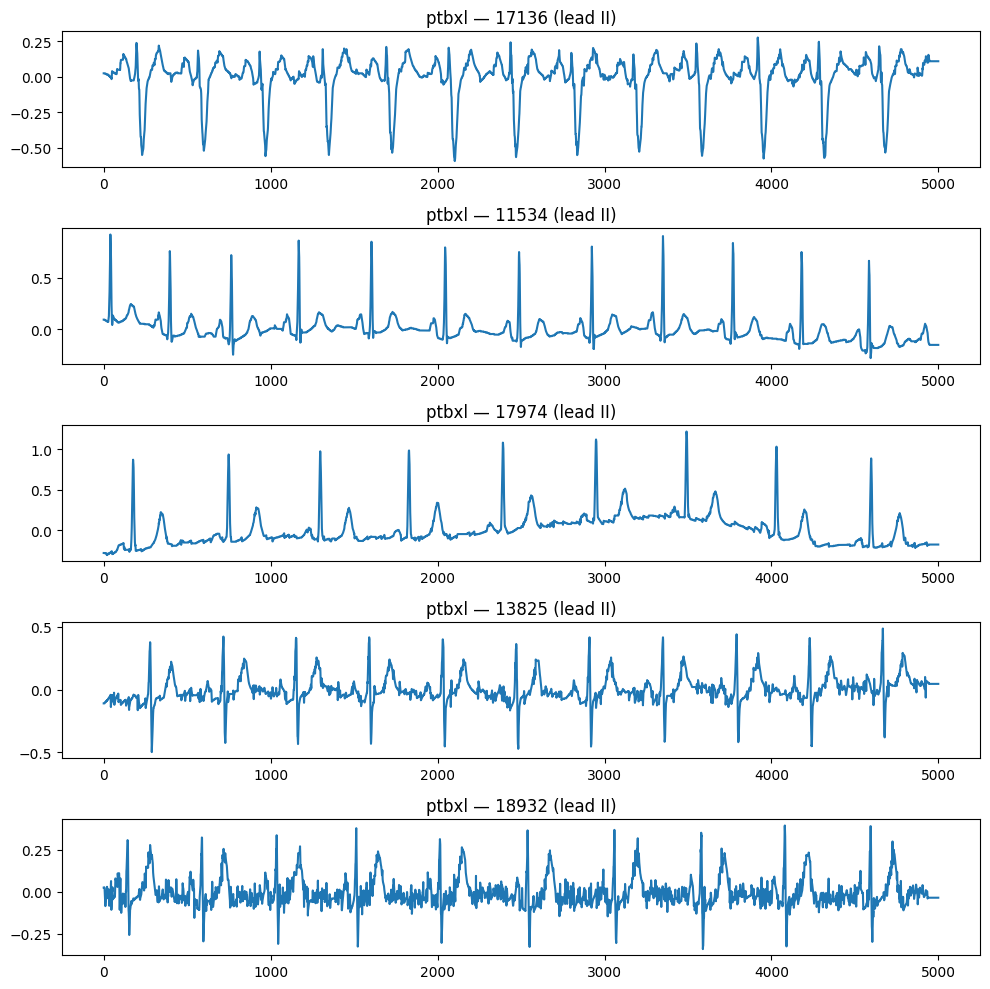

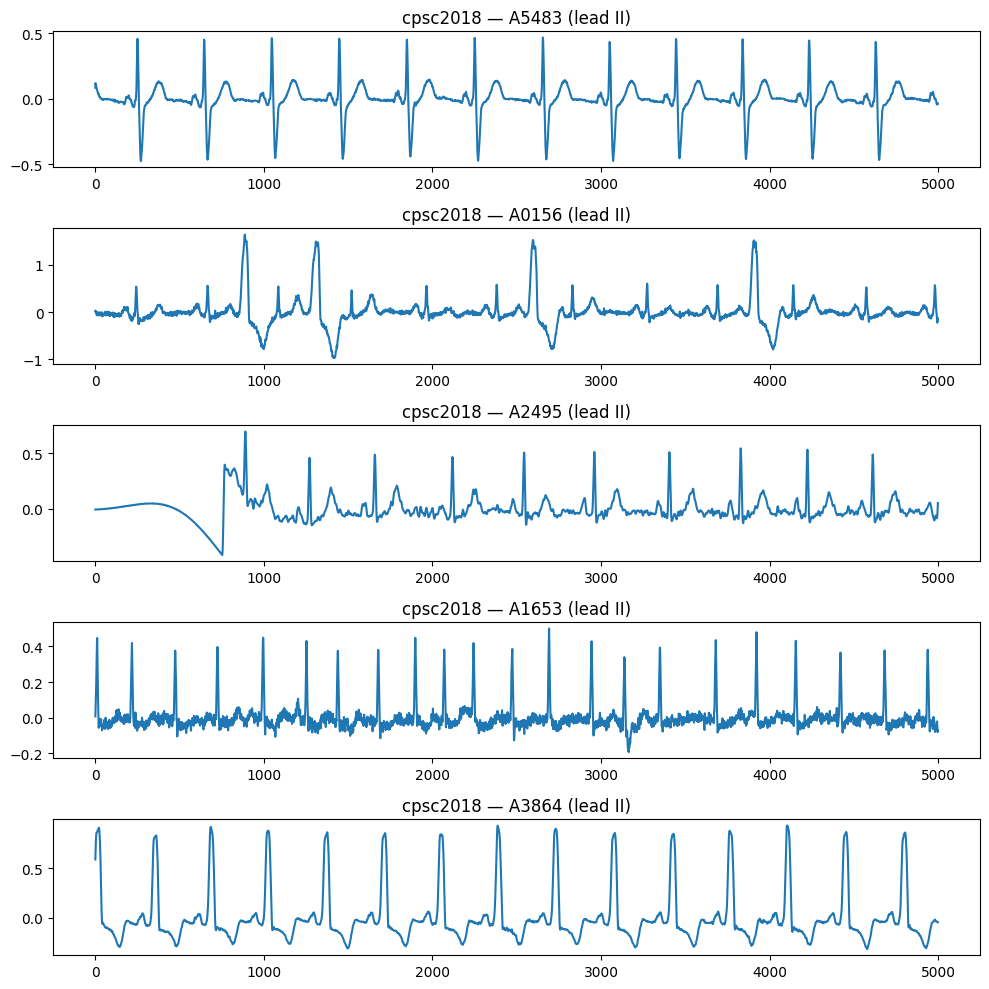


Done. Cleaned data + index CSVs + sanity plots are saved under:
/content/drive/MyDrive/ecg_benchmark/processed
You can now delete /content/raw to free up session disk space.


In [ ]:
def sanity_report(index_df, dataset_name):
    total = len(index_df)
    errors = index_df['error'].notna().sum() if 'error' in index_df else 0
    ok = index_df[index_df.get('error').isna()] if 'error' in index_df else index_df

    print(f"\n=== {dataset_name} sanity report ===")
    print(f"Total attempted: {total}")
    print(f"Errors: {errors}")
    if 'has_nan' in ok:
        print(f"NaN recordings: {ok['has_nan'].sum()}")
    if 'is_flatline' in ok:
        print(f"Flatline recordings: {ok['is_flatline'].sum()}")
    if 'shape_ok' in ok:
        print(f"Shape mismatches: {(~ok['shape_ok']).sum()}")

sanity_report(ptbxl_index, "PTB-XL")
sanity_report(cpsc_index, "CPSC2018")


def plot_random_samples(index_df, dataset_name, n=5):
    valid = index_df[index_df.get('error').isna()] if 'error' in index_df else index_df
    sample = valid.sample(min(n, len(valid)), random_state=SEED)

    fig, axes = plt.subplots(n, 1, figsize=(10, 2 * n))
    for ax, (_, row) in zip(axes, sample.iterrows()):
        sig = np.load(row['file'])
        ax.plot(sig[1])  # plot lead II as a representative channel
        ax.set_title(f"{dataset_name} — {row['ecg_id']} (lead II)")
    plt.tight_layout()
    plt.savefig(f'{PROCESSED_DIR}/{dataset_name}_sample_plot.png')
    plt.show()

plot_random_samples(ptbxl_index, "ptbxl")
plot_random_samples(cpsc_index, "cpsc2018")

print("\nDone. Cleaned data + index CSVs + sanity plots are saved under:")
print(PROCESSED_DIR)
print("You can now delete /content/raw to free up session disk space.")


In [ ]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /


In [ ]:
# Code-15% Dataset
!wget -O exams.csv "https://zenodo.org/records/4916206/files/exams.csv?download=1"

--2026-08-17 03:20:10--  https://zenodo.org/records/4916206/files/exams.csv?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 35500900 (34M) [text/plain]
Saving to: ‘exams.csv’

exams.csv           100%[===================>]  33.86M  1.54MB/s    in 26s     

2026-08-17 03:20:36 (1.30 MB/s) - ‘exams.csv’ saved [35500900/35500900]



In [ ]:
!wget -O exams_part0.zip "https://zenodo.org/records/4916206/files/exams_part0.zip?download=1"


--2026-08-17 03:20:36--  https://zenodo.org/records/4916206/files/exams_part0.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2672786404 (2.5G) [application/octet-stream]
Saving to: ‘exams_part0.zip’

exams_part0.zip     100%[===================>]   2.49G  5.97MB/s    in 19m 54s 

2026-08-17 03:40:31 (2.13 MB/s) - ‘exams_part0.zip’ saved [2672786404/2672786404]



In [ ]:
!unzip -q exams_part0.zip -d exams_part0

In [ ]:
import pandas as pd
import h5py

# Load the labels
df = pd.read_csv("exams.csv")
print(df.shape)
print(df.head())

# Load the waveform file (adjust filename if it's different after unzipping — check with !ls exams_part0)
f = h5py.File("exams_part0/exams_part0.hdf5", "r")
print(f.keys())          # should show 'tracings' and 'exam_id'
print(f["tracings"].shape)  # should be (N, 4096, 12)

(345779, 15)
   exam_id  age  is_male  nn_predicted_age  1dAVb   RBBB   LBBB     SB     ST  \
0  1169160   38     True         40.160484  False  False  False  False  False   
1  2873686   73     True         67.059440  False  False  False  False  False   
2   168405   67     True         79.621740  False  False  False  False  False   
3   271011   41     True         69.750260  False  False  False  False  False   
4   384368   73     True         78.873460  False  False  False  False  False   

      AF  patient_id  death     timey  normal_ecg         trace_file  
0  False      523632  False  2.098628        True  exams_part13.hdf5  
1  False     1724173  False  6.657529       False  exams_part13.hdf5  
2   True       51421  False  4.282188       False  exams_part13.hdf5  
3  False     1737282  False  4.038353        True  exams_part13.hdf5  
4  False      331652  False  3.786298       False  exams_part13.hdf5  
<KeysViewHDF5 ['exam_id', 'tracings']>
(20001, 4096, 12)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("exams.csv")

print("Age summary:")
print(df["age"].describe())

print("\nSex breakdown:")
print(df["is_male"].value_counts(normalize=True))

Age summary:
count    345779.000000
mean         53.240495
std          19.695125
min          17.000000
25%          37.000000
50%          54.000000
75%          70.000000
max         100.000000
Name: age, dtype: float64

Sex breakdown:
is_male
False    0.597422
True     0.402578
Name: proportion, dtype: float64


In [ ]:
!wget -q -O ptbxl_database.csv "https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv"
print("done")

done


In [ ]:
!wget -q -r -N -c -np -A "*.hea" https://physionet.org/files/challenge-2020/1.0.2/training/georgia/
print("done")

done


In [ ]:
!wget -q -r -N -c -np -A "*.hea" https://physionet.org/files/challenge-2020/1.0.2/training/cpsc_2018/
print("done")

done


In [ ]:
!wget -q -O ptbxl_database.csv "https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv"
print("done")

done


In [ ]:
import glob

files = glob.glob("physionet.org/files/challenge-2020/1.0.2/training/georgia/**/*.hea", recursive=True)
print("Found:", len(files))
print("First file path:", files[0])
print("---content---")
with open(files[0]) as f:
    print(f.read())

Found: 10344
First file path: physionet.org/files/challenge-2020/1.0.2/training/georgia/g6/E05041.hea
---content---
E05041 12 500 5000
E05041.mat 16x1+24 1000.0(0)/mV 16 0 -68 27569 0 I
E05041.mat 16x1+24 1000.0(0)/mV 16 0 -29 -18689 0 II
E05041.mat 16x1+24 1000.0(0)/mV 16 0 39 19720 0 III
E05041.mat 16x1+24 1000.0(0)/mV 16 0 48 -4660 0 aVR
E05041.mat 16x1+24 1000.0(0)/mV 16 0 -53 3567 0 aVL
E05041.mat 16x1+24 1000.0(0)/mV 16 0 4 593 0 aVF
E05041.mat 16x1+24 1000.0(0)/mV 16 0 68 -7791 0 V1
E05041.mat 16x1+24 1000.0(0)/mV 16 0 -58 -21449 0 V2
E05041.mat 16x1+24 1000.0(0)/mV 16 0 0 8348 0 V3
E05041.mat 16x1+24 1000.0(0)/mV 16 0 -58 -25884 0 V4
E05041.mat 16x1+24 1000.0(0)/mV 16 0 -126 -3672 0 V5
E05041.mat 16x1+24 1000.0(0)/mV 16 0 -78 -4706 0 V6
# Age: 88
# Sex: Female
# Dx: 427393009
# Rx: Unknown
# Hx: Unknown



In [ ]:
import re
import glob

def parse_hea_files(pattern, dataset_name):
    records = []
    for path in glob.glob(pattern, recursive=True):
        with open(path) as f:
            text = f.read()
        age_match = re.search(r"#\s*Age:\s*(\S+)", text, re.IGNORECASE)
        sex_match = re.search(r"#\s*Sex:\s*(\S+)", text, re.IGNORECASE)
        if age_match and sex_match:
            age = age_match.group(1)
            sex = sex_match.group(1)
            if age.replace(".", "").isdigit():
                records.append({
                    "dataset": dataset_name,
                    "age": float(age),
                    "is_male": sex.lower().startswith("m"),
                })
    return pd.DataFrame(records)

georgia_df = parse_hea_files("physionet.org/files/challenge-2020/1.0.2/training/georgia/**/*.hea", "Georgia")
cpsc_df = parse_hea_files("physionet.org/files/challenge-2020/1.0.2/training/cpsc_2018/**/*.hea", "CPSC2018")
chapman_df = parse_hea_files("physionet.org/files/ecg-arrhythmia/1.0.0/WFDBRecords/**/*.hea", "Chapman-Shaoxing-Ningbo")
print("Chapman-Shaoxing-Ningbo rows found:", len(chapman_df))

print("Georgia:", georgia_df.shape)
print("CPSC:", cpsc_df.shape)

Chapman-Shaoxing-Ningbo rows found: 0
Georgia: (10267, 3)
CPSC: (6868, 3)


In [ ]:
ptbxl_raw = pd.read_csv("ptbxl_database.csv")
print(ptbxl_raw["sex"].unique())


[1 0]


In [ ]:
ptbxl_df = pd.DataFrame({
    "dataset": "PTB-XL",
    "age": ptbxl_raw["age"],
    "is_male": ptbxl_raw["sex"] == 0,  # <- confirm this mapping against the printed output first
})

code15_df = pd.DataFrame({
    "dataset": "CODE-15%",
    "age": df["age"],
    "is_male": df["is_male"],
})

all_data = pd.concat([ptbxl_df, georgia_df, cpsc_df, code15_df, chapman_df], ignore_index=True)
all_data = all_data.dropna(subset=["age"])
all_data = all_data[(all_data["age"] > 0) & (all_data["age"] < 120)]

print(all_data.groupby("dataset").size())

dataset
CODE-15%    345779
CPSC2018      6868
Georgia      10267
PTB-XL       21506
dtype: int64


In [ ]:
metadata = {
    "PTB-XL":    {"sampling_rate": 500, "label_schema": "SCP-ECG"},
    "Georgia":   {"sampling_rate": 500, "label_schema": "SNOMED-CT"},
    "CPSC2018":  {"sampling_rate": 500, "label_schema": "CPSC-9class"},
    "CODE-15%":  {"sampling_rate": 400, "label_schema": "CODE-6class"},
    "Chapman-Shaoxing-Ningbo": {"sampling_rate": 500, "label_schema": "SNOMED-CT"},
}

In [ ]:
!wget -q -r -N -c -np -A "*.hea" https://physionet.org/files/ecg-arrhythmia/1.0.0/WFDBRecords/
print("done")

done


In [ ]:
metadata["Chapman-Shaoxing-Ningbo"] = {"sampling_rate": 500, "label_schema": "SNOMED-CT"}

In [ ]:
import numpy as np
from scipy.stats import entropy
from itertools import permutations

def age_distribution(ages, bins=np.arange(0, 101, 10)):
    counts, _ = np.histogram(ages, bins=bins)
    counts = counts + 1  # Laplace smoothing: avoids divide-by-zero when a bin is empty in one dataset
    return counts / counts.sum()

def sex_distribution(is_male_series):
    n_male = is_male_series.sum() + 1
    n_female = (~is_male_series).sum() + 1
    total = n_male + n_female
    return np.array([n_male / total, n_female / total])

datasets = all_data["dataset"].unique()
rows = []

for a, b in permutations(datasets, 2):  # ordered pairs, so A→B and B→A are both included
    ages_a = all_data[all_data["dataset"] == a]["age"]
    ages_b = all_data[all_data["dataset"] == b]["age"]
    sex_a = all_data[all_data["dataset"] == a]["is_male"]
    sex_b = all_data[all_data["dataset"] == b]["is_male"]

    age_kl = entropy(age_distribution(ages_a), age_distribution(ages_b))
    sex_kl = entropy(sex_distribution(sex_a), sex_distribution(sex_b))

    rows.append({
        "dataset_from": a,
        "dataset_to": b,
        "age_kl": age_kl,
        "sex_kl": sex_kl,
        "ps_score": age_kl + sex_kl,
    })

kl_df = pd.DataFrame(rows)
print(kl_df.sort_values("ps_score", ascending=False))


   dataset_from dataset_to    age_kl    sex_kl  ps_score
10     CODE-15%    Georgia  0.203479  0.036481  0.239960
8      CPSC2018   CODE-15%  0.143328  0.037397  0.180725
5       Georgia   CODE-15%  0.129645  0.036885  0.166530
7      CPSC2018    Georgia  0.161887  0.000002  0.161889
9      CODE-15%     PTB-XL  0.108832  0.029999  0.138830
2        PTB-XL   CODE-15%  0.094700  0.030362  0.125062
11     CODE-15%   CPSC2018  0.087044  0.036991  0.124035
6      CPSC2018     PTB-XL  0.118687  0.000366  0.119053
4       Georgia   CPSC2018  0.069146  0.000002  0.069147
0        PTB-XL    Georgia  0.048896  0.000317  0.049213
1        PTB-XL   CPSC2018  0.045207  0.000366  0.045573
3       Georgia     PTB-XL  0.021186  0.000317  0.021502


In [ ]:
print(kl_df.shape)

(12, 8)


In [ ]:
# Bootstrap the "null" distribution: split CODE-15% (your largest, real dataset)
# in half repeatedly and measure KL divergence between two halves of the SAME population.
# This tells us how much divergence shows up just from random sampling noise,
# with zero true population shift.

rng = np.random.default_rng(42)
code15_ages = all_data[all_data["dataset"] == "CODE-15%"]["age"].values
code15_sex = all_data[all_data["dataset"] == "CODE-15%"]["is_male"].values

null_scores = []
for _ in range(200):
    idx = rng.permutation(len(code15_ages))
    half = len(idx) // 2
    a_idx, b_idx = idx[:half], idx[half:]

    age_kl = entropy(age_distribution(code15_ages[a_idx]), age_distribution(code15_ages[b_idx]))
    sex_kl = entropy(
        sex_distribution(pd.Series(code15_sex[a_idx])),
        sex_distribution(pd.Series(code15_sex[b_idx]))
    )
    null_scores.append(age_kl + sex_kl)

null_scores = np.array(null_scores)
ps_threshold = np.percentile(null_scores, 95)
print(f"Null distribution mean: {null_scores.mean():.4f}")
print(f"PS threshold (95th percentile of null): {ps_threshold:.4f}")

Null distribution mean: 0.0001
PS threshold (95th percentile of null): 0.0001


In [ ]:
metadata["Chapman-Shaoxing-Ningbo"] = {"sampling_rate": 500, "label_schema": "SNOMED-CT"}

def ds_flag(a, b):
    return int(metadata[a]["sampling_rate"] != metadata[b]["sampling_rate"])

def ls_flag(a, b):
    return int(metadata[a]["label_schema"] != metadata[b]["label_schema"])

kl_df["PS"] = (kl_df["ps_score"] > ps_threshold).astype(int)
kl_df["DS"] = kl_df.apply(lambda r: ds_flag(r["dataset_from"], r["dataset_to"]), axis=1)
kl_df["LS"] = kl_df.apply(lambda r: ls_flag(r["dataset_from"], r["dataset_to"]), axis=1)

print(kl_df.shape)

(12, 8)


In [ ]:
output = kl_df[["dataset_from", "dataset_to", "age_kl", "sex_kl", "ps_score", "PS", "DS", "LS"]]
output.to_csv("shift_vectors.csv", index=False)
print("Saved shift_vectors.csv with", len(output), "rows")

Saved shift_vectors.csv with 12 rows


In [ ]:
!find . -name "*.hea" | head -5

./physionet.org/files/challenge-2020/1.0.2/training/georgia/g6/E05041.hea
./physionet.org/files/challenge-2020/1.0.2/training/georgia/g6/E05361.hea
./physionet.org/files/challenge-2020/1.0.2/training/georgia/g6/E05198.hea
./physionet.org/files/challenge-2020/1.0.2/training/georgia/g6/E05884.hea
./physionet.org/files/challenge-2020/1.0.2/training/georgia/g6/E05760.hea


In [ ]:
print(kl_df.shape)
print(sorted(kl_df["dataset_from"].unique()))

(12, 8)
['CODE-15%', 'CPSC2018', 'Georgia', 'PTB-XL']


In [ ]:
!find . -path "*ecg-arrhythmia*" -name "*.hea" | wc -l

8555


In [ ]:
print(kl_df.shape)
print(sorted(kl_df["dataset_from"].unique()))

(12, 8)
['CODE-15%', 'CPSC2018', 'Georgia', 'PTB-XL']


In [ ]:
# 1. Shape and dataset count
print(kl_df.shape)  # expect (20, 8)

# 2. No missing values anywhere
print(kl_df.isna().sum().sum())  # expect 0

# 3. PS/DS/LS are clean binary columns
print(kl_df[["PS", "DS", "LS"]].apply(lambda c: sorted(c.unique())))  # expect [0, 1] for each

# 4. Threshold produces a reasonable split (not all-0 or all-1)
print(f"PS=1 count: {kl_df['PS'].sum()} of 20")

# 5. Save and reload
kl_df.to_csv("shift_vectors.csv", index=False)
check = pd.read_csv("shift_vectors.csv")
print(check.shape)  # expect (20, 8)

(12, 8)
0
PS       [1]
DS    [0, 1]
LS       [1]
dtype: object
PS=1 count: 12 of 20
(12, 8)


In [ ]:
kl_df.to_csv("shift_vectors.csv", index=False)
print("saved")

saved


In [ ]:
check = pd.read_csv("shift_vectors.csv")
print(check.shape)      # should print (20, 8)
print(check.head())     # eyeball the first few rows

(12, 8)
  dataset_from dataset_to    age_kl    sex_kl  ps_score  PS  DS  LS
0       PTB-XL    Georgia  0.048896  0.000317  0.049213   1   0   1
1       PTB-XL   CPSC2018  0.045207  0.000366  0.045573   1   0   1
2       PTB-XL   CODE-15%  0.094700  0.030362  0.125062   1   1   1
3      Georgia     PTB-XL  0.021186  0.000317  0.021502   1   0   1
4      Georgia   CPSC2018  0.069146  0.000002  0.069147   1   0   1


In [ ]:
print("Chapman rows:", len(chapman_df))

Chapman rows: 0
